In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# Load dataset (semicolon-separated)
data = pd.read_csv("bank.csv", sep=';')


In [4]:
print("First 5 rows of the dataset:")
data.head()


First 5 rows of the dataset:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [5]:
# Independent variables
X = data.drop("y", axis=1)

# Dependent variable
y = data["y"]

In [6]:
print("Missing values before handling:")
print(X.isnull().sum())


Missing values before handling:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


In [7]:
# Replace missing categorical values with mode
for col in X.select_dtypes(include="object").columns:
    X[col].fillna(X[col].mode()[0], inplace=True)

# Replace missing numerical values with mean
for col in X.select_dtypes(include=["int64", "float64"]).columns:
    X[col].fillna(X[col].mean(), inplace=True)

print("\nMissing values after handling:")
print(X.isnull().sum())



Missing values after handling:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


C:\Users\Atharv\AppData\Local\Temp\ipykernel_13336\517578220.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].mode()[0], inplace=True)
C:\Users\Atharv\AppData\Local\Temp\ipykernel_13336\517578220.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [8]:
label_encoder = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = label_encoder.fit_transform(X[col])

# Encode target variable
y = label_encoder.fit_transform(y)


In [19]:
print(X.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   30   10        1          0        0     1787        0     0        0   
1   33    7        1          1        0     4789        1     1        0   
2   35    4        2          2        0     1350        1     0        0   
3   30    4        1          2        0     1476        1     1        2   
4   59    1        1          1        0        0        1     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  
0   19     10        79         1     -1         0         3  
1   11      8       220         1    339         4         0  
2   16      0       185         1    330         1         0  
3    3      6       199         4     -1         0         3  
4    5      8       226         1     -1         0         3  


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
dt_temp = DecisionTreeClassifier(random_state=42)
dt_temp.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_temp.feature_importances_
})

feature_importance.sort_values(by="Importance", ascending=False)


,Feature,Importance
11,duration,0.258636
9,day,0.146790
5,balance,0.135673
0,age,0.099244
13,pdays,0.082172
10,month,0.064929
1,job,0.057127
15,poutcome,0.056011
12,campaign,0.026560
2,marital,0.020737


In [12]:
dt_classifier = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)


In [13]:
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [14]:
y_pred = dt_classifier.predict(X_test)


In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.8718232044198895


In [16]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[743  64]
 [ 52  46]]


In [17]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       807
           1       0.42      0.47      0.44        98

    accuracy                           0.87       905
   macro avg       0.68      0.70      0.68       905
weighted avg       0.88      0.87      0.88       905



In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    dt_classifier, X, y, cv=kfold
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.8718232  0.87721239 0.87389381 0.86061947 0.86836283]
Mean CV Accuracy: 0.870382339999022


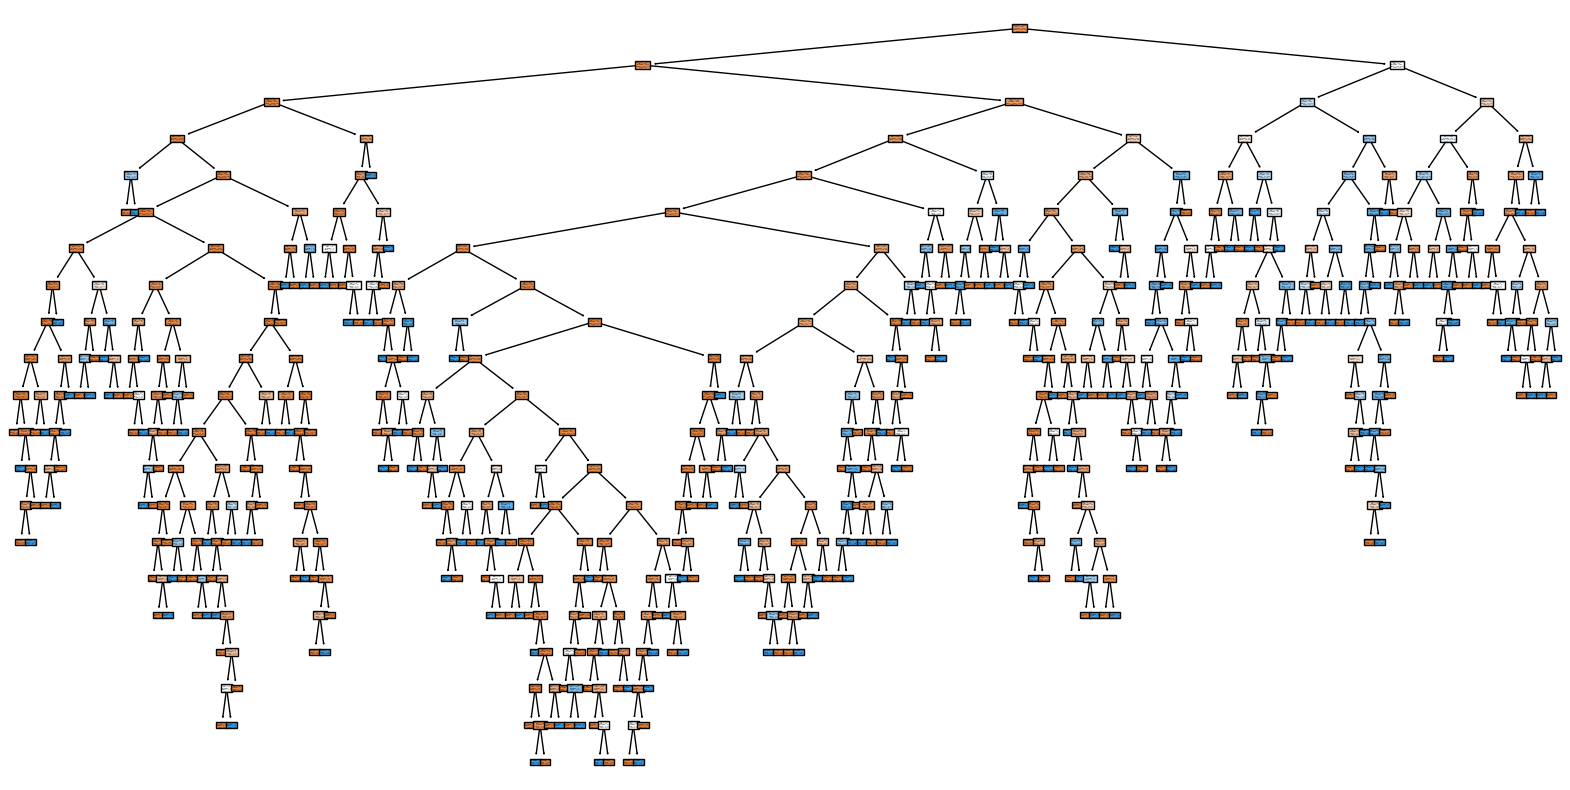

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(dt_classifier, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.show()